In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the best model (Gradient Boosting)
model = joblib.load('../models/best_model.pkl')

# Loading the test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

In [2]:
# Building a TreeExplainer for fast, exact SHAP values
explainer = shap.TreeExplainer(model)

# Computing SHAP values on the test set
shap_values = explainer(X_test)


In [3]:
explainer

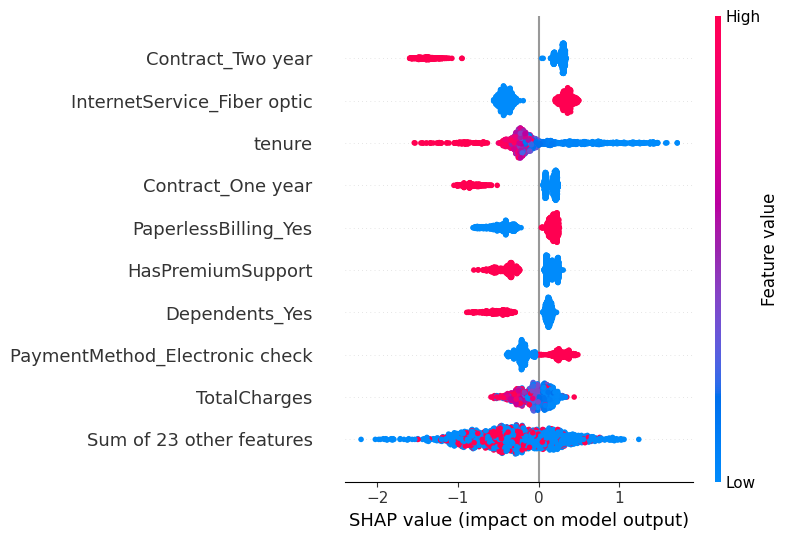

In [4]:
# Generating the SHAP beeswarm summary plot
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Calculating mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

# Taking top 5 features
top_5 = feature_importance.head(5).copy()

# Mapping technical feature names to business-friendly labels
label_map = {
    'Contract_Month-to-month': 'Month-to-month contract',
    'tenure': 'Tenure (months as customer)',
    'MonthlyCharges': 'High monthly charges',
    'HasPremiumSupport': 'No premium support',
    'InternetService_Fiber optic': 'Fiber optic internet'
}
top_5['label'] = top_5['feature'].map(label_map).fillna(top_5['feature'])

In [6]:
#print(mean_abs_shap)
print(feature_importance)
#print(top_5)

                                  feature  importance
27                      Contract_Two year    0.538891
12            InternetService_Fiber optic    0.384058
1                                  tenure    0.370963
26                      Contract_One year    0.308882
28                   PaperlessBilling_Yes    0.293477
5                       HasPremiumSupport    0.269494
8                          Dependents_Yes    0.247031
30         PaymentMethod_Electronic check    0.235111
3                            TotalCharges    0.149813
15                     OnlineSecurity_Yes    0.130105
29  PaymentMethod_Credit card (automatic)    0.129704
2                          MonthlyCharges    0.124826
11                      MultipleLines_Yes    0.123944
31             PaymentMethod_Mailed check    0.099257
0                           SeniorCitizen    0.084129
21                        TechSupport_Yes    0.081597
17                       OnlineBackup_Yes    0.079667
25                    Stream

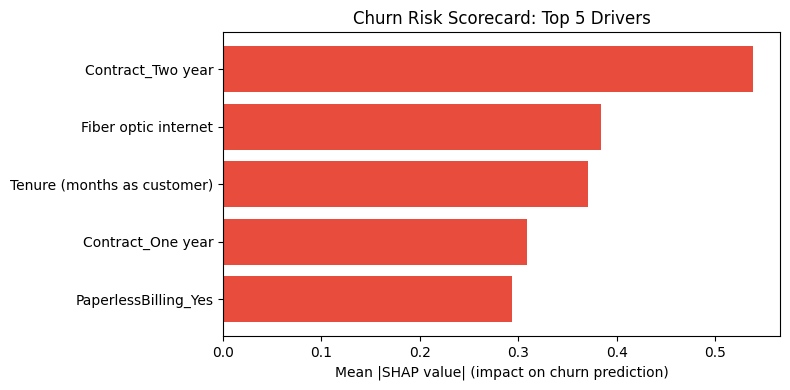

In [7]:
# Creating the Churn Risk Scorecard
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_5['label'], top_5['importance'], color='#e74c3c')
ax.set_xlabel('Mean |SHAP value| (impact on churn prediction)')
ax.set_title('Churn Risk Scorecard: Top 5 Drivers')
ax.invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.savefig('../reports/figures/churn_risk_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()